In [1]:
# Colab setup -- installs SoftMobility when running on Google Colab.
try:
    import google.colab  # noqa: F401
    %pip install -q git+https://github.com/C0PEP0D/SoftMobility.git
except ImportError:
    pass

# Example 06. Soft Jeffery's orbits

Tumbling dynamics of a near-rigid body with a small compliant cilium in
simple shear flow, using the library's `FlowBodyRollout` and
**tutorial-14 conventions** (natural axis along body $\hat{\mathbf{x}}$,
spherical $(\varphi, \theta)$ of the natural axis in lab).

**Body** — a main sphere ($a_0 = 1$) at body-frame origin plus a small
cilium sphere ($a_1 = 0.1$) attached at $(1, 0, 0)$, swinging in the
$xy_\text{body}$ plane at angle $\theta$ from body
$\hat{\mathbf{x}}$.  $\theta$ is the elastic deviation, restored by a
torsional spring of stiffness $k$.

**Natural axis** — the sphere0→sphere1 line in body frame, which
coincides with body $\hat{\mathbf{x}}$.  In the rigid limit it is the
body's symmetry axis and the closed-form Jeffery orbit applies to its
lab-frame direction $\mathbf{p}(t) = \mathcal{R}(t)\,\hat{\mathbf{e}}_\text{nat,body}$.

**Shear flow** $\mathbf{u} = \dot\gamma\,y\,\hat{\mathbf{e}}_x$,
$\dot\gamma = 1$.

## What we show

* **Three S² orbits** of $\mathbf{p}(t)$ for rigid, medium and soft cases.
  The rigid simulation is compared to the closed-form Jeffery orbit as
  a sanity check.
* **Time series** of $(\theta, \varphi, \gamma, \theta_\text{dof})$ over
  two ranges (2 and 100 Jeffery periods), three cases overlaid.
* **Poincaré map** in the $(\gamma, \theta)$ plane at $\varphi = 0$
  for the soft case, sweeping initial polar $\theta_0 \in (0, \pi)$.


## Imports

In [2]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import softmobility as sm
from softmobility.classes import figstyle

jax.config.update("jax_enable_x64", True)
figstyle.apply()
np.set_printoptions(precision=4, linewidth=120, suppress=True, sign=" ")

FIGDIR = "figures"

## 1. Soft body construction

Body $\hat{\mathbf{x}}$ is the main-sphere surface normal (cilium
attachment direction).  The cilium swings in the $xy_\text{body}$ plane
about body $\hat{\mathbf{z}}$.  Rest configuration: cilium aligned with
body $\hat{\mathbf{x}}$; $\theta$ is the elastic deviation, restored by
a torsional spring of stiffness $k$.


In [3]:
yaml_data = """
dof_names:    [theta]
design_names: [stiffness, length, a_small]

defaults:
  stiffness: 1
  length:    0.2
  theta:     0.0
  a_small:   0.1

spheres:
  - radius: 1
    torque: [0, 0, stiffness * theta]

  - radius: a_small
    position:
      - 1 + length * cos(theta)
      - length * sin(theta)
      - 0
    orientation: [0, 0, theta]
    torque: [0, 0, -stiffness * theta]
"""

mybody = sm.SoftBody(yaml_data, verbose=False, allow_overlap=True)
print("dof_variables:    ", mybody.dof_variables)
print("design_variables: ", mybody.design_variables)
print("design_defaults:  ", np.asarray(mybody.design_defaults))

A_SMALL_IDX   = mybody.design_variables.index("a_small")
LENGTH_IDX    = mybody.design_variables.index("length")
STIFFNESS_IDX = mybody.design_variables.index("stiffness")

a_small = float(mybody.design_defaults[A_SMALL_IDX])
length  = float(mybody.design_defaults[LENGTH_IDX])

dof_variables:     ['theta']
design_variables:  ['a_small', 'length', 'stiffness']
design_defaults:   [ 0.1  0.2  1. ]


## 2. Body geometry

Sphere 1 at the cilium rest ($\theta = 0$) sits at body-frame
$(1 + \ell,\ 0,\ 0)$.  The natural axis $\hat{\mathbf{e}}_\text{nat}$ is
this direction; it coincides with body $\hat{\mathbf{x}}$.


Sphere 1 at theta=0 body frame: (1.2000, 0.0000, 0)
Natural axis length R = 1.2000
Gap = 0.1000
ê_nat_body  = [ 1.  0.  0.]
ê_perp_body = [ 0.  1.  0.]


PosixPath('figures/fig_proto21_geometry.pdf')

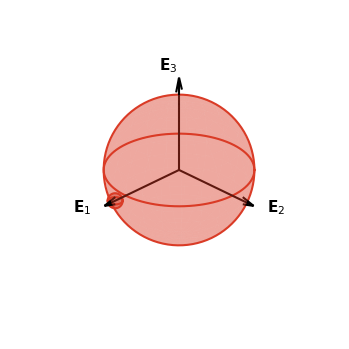

In [4]:
x1 = 1.0 + length
y1 = 0.0
R_natural = x1

# Natural axis and a body-frame perpendicular in the cilium (xy) plane:
e_nat_body  = np.array([1.0, 0.0, 0.0])
e_perp_body = np.array([0.0, 1.0, 0.0])

print(f"Sphere 1 at theta=0 body frame: ({x1:.4f}, {y1:.4f}, 0)")
print(f"Natural axis length R = {R_natural:.4f}")
print(f"Gap = {R_natural - 1 - a_small:.4f}")
print(f"ê_nat_body  = {e_nat_body}")
print(f"ê_perp_body = {e_perp_body}")

fig_geom, ax_geom = figstyle.figure_3d(size="half", aspect=1.0)
figstyle.add_body_axes(ax_geom, length=1.4, show_labels=True)
figstyle.add_sphere(ax_geom, [0, 0, 0], 1.0)
figstyle.add_sphere(ax_geom, [x1, y1, 0], a_small)
ax_geom.set_xlim(-1.3, 1.3)
ax_geom.set_ylim(-1.3, 1.3)
ax_geom.set_zlim(-1.3, 1.3)
figstyle.displace_label(ax_geom, "axis_label_E1", text=r"$\mathbf{E}_1$", offset=(0.3, 0, 0))
figstyle.displace_label(ax_geom, "axis_label_E2", text=r"$\mathbf{E}_2$", offset=(0, 0.3, 0))
figstyle.displace_label(ax_geom, "axis_label_E3", text=r"$\mathbf{E}_3$", offset=(0.2, 0, 0))
figstyle.save(fig_geom, "fig_proto21_geometry", figdir=FIGDIR)

## 3. Bretherton parameter (rigid limit)

Built from a parallel rigid YAML in the natural-axis-aligned frame
(sphere 0 at origin, sphere 1 at $(R_\text{nat}, 0, 0)$) so that
`C_E[-1, 1]` cleanly returns $B$.  Only used to (i) overlay the
Jeffery analytical orbit on the rigid S² figure and (ii) normalise
time axes.


In [ ]:
SHEAR_RATE = 1.0
shear_flow = sm.shear_flow(shear_rate=SHEAR_RATE)

bretherton_yaml = f"""
spheres:
  - radius: 1
  - radius: {a_small}
    position: [{R_natural}, 0, 0]
"""
bretherton_body = sm.SoftBody(bretherton_yaml, verbose=False, allow_overlap=True)
B = float(bretherton_body.compute_rigid_tensors().C_E[-1, 1])
c_factor = np.sqrt((1 + B) / (1 - B))
T_jeffery = 2 * np.pi * (c_factor + 1 / c_factor) / SHEAR_RATE
print(f"Bretherton B = {B:.6f}")
print(f"c = sqrt((1+B)/(1-B)) = {c_factor:.4f}")
print(f"Jeffery period T = {T_jeffery:.4f}  (sphere limit 4π = {4*np.pi:.4f})")

## 4. Three-case simulation

Same initial orientation for all three cases; $100$ tumbling periods
at $dt = 0.001$ (RK4 needs the small step in this near-contact
geometry).

Initial orientation $(0, -0.6, 0)$ puts the natural axis at lab polar
$\theta(0) \approx 0.97$ rad.

We capture the internal DOF time series alongside the orientation.
For the rigid case there is no DOF, so we store a zero array of
matching shape.


In [6]:
# Truly rigid body: no DOFs, sphere 1 pinned at its theta=0 position
rigid_pinned_yaml = f"""
spheres:
  - radius: 1
  - radius: {a_small}
    position: [{x1}, {y1}, 0]
"""
rigid_body_pinned = sm.SoftBody(rigid_pinned_yaml, verbose=False, allow_overlap=True)

dt = 0.001
N_PERIODS = 100
n_steps = int(N_PERIODS * T_jeffery / dt)
t = (np.arange(n_steps) + 1) * dt
init_orientation = jnp.array([0.0, -0.6, 0.0])

cases = [
    ("rigid",  rigid_body_pinned, None),
    ("medium", mybody,            jnp.asarray([a_small, length, 1.0])),
    ("soft",   mybody,            jnp.asarray([a_small, length, 0.1])),
]
results = {}
for name, body, design in cases:
    rollout = sm.FlowBodyRollout(soft_body=body, flow=shear_flow)
    if design is None:
        _, oris, dofs = rollout.rollout(dt=dt, n_steps=n_steps, init_orientation=init_orientation)
    else:
        _, oris, dofs = rollout.rollout(dt=dt, n_steps=n_steps, init_orientation=init_orientation,
                                        design=design)
    oris_np = np.array(oris, copy=True)
    dofs_np = np.array(dofs, copy=True)
    if dofs_np.ndim == 2 and dofs_np.shape[1] == 0:
        dofs_np = np.zeros((oris_np.shape[0], 1))
    results[name] = {"oris": oris_np, "dofs": dofs_np}
    print(f"  {name:6s}: n_steps = {n_steps}, dofs shape = {dofs_np.shape}, "
          f"any NaN? {bool(np.isnan(oris_np).any())}")

  rigid : n_steps = 1260937, dofs shape = (1260937, 1), any NaN? False


  medium: n_steps = 1260937, dofs shape = (1260937, 1), any NaN? False


  soft  : n_steps = 1260937, dofs shape = (1260937, 1), any NaN? False


/Users/Ch/Documents/Python/SoftMobility/softmobility/classes/softbody.py:429: UserWarning: GRPY mobility entered the partial-overlap regime (|a_i − a_j| < R < a_i + a_j, spheres strictly overlapping) during a rollout. Further occurrences are suppressed; call SoftBody.reset_overlap_warnings() to re-enable.
  _emit_overlap_warning(saw_medium, saw_near, allow_overlap=self.allow_overlap)


## 5. Extract $\mathbf{p}(t)$, spherical $(\varphi, \theta)$ and spin $\gamma$

Following tutorial 14, $\mathbf{p}(t) = \mathcal{R}(t)\,\hat{\mathbf{e}}_\text{nat,body}$
is the lab-frame direction of the body's natural axis.

For $\gamma$ we use the perpendicular body-frame direction
$\hat{\mathbf{e}}_\perp = \hat{\mathbf{y}}_\text{body}$.  In lab,
$\mathbf{q}(t) = \mathcal{R}(t)\,\hat{\mathbf{e}}_\perp$ lies in the plane
$\perp\!\mathbf{p}(t)$; comparing its angle in that plane against the
projection of lab $\hat{\mathbf{z}}$ defines the spin $\gamma(t)$.

We keep $\varphi$ and $\gamma$ in $(-\pi, \pi]$ (no unwrap), so the
time series show the natural sawtooth jumps at the branch cut.


In [7]:
@jax.jit
def lab_from_ori(ori, e_body):
    return sm.rotation_matrix(ori) @ e_body


def phi_theta_of_p(p):
    """Spherical angles (φ, θ) of a unit vector p with θ measured from e3."""
    p = np.asarray(p)
    phi = np.arctan2(p[..., 1], p[..., 0])
    theta = np.arccos(p[..., 2])
    return phi, theta


def phi_theta_gamma_from_ori(ori, e_nat_body, e_perp_body):
    """Signed spin about p, using lab e3 projected ⊥p as the reference direction."""
    R = sm.rotation_matrix(ori)
    Z = R @ e_nat_body
    X = R @ e_perp_body
    Y = R @ jnp.cross(e_nat_body, e_perp_body)
    theta = jnp.arccos(Z[..., 2])
    phi = jnp.arctan2(Z[..., 1], Z[..., 0])
    sintheta = jnp.sin(theta)
    gamma = jnp.arctan2(-X[..., 2] / sintheta, Y[..., 2] / sintheta)
    return phi, theta, gamma


def jeffery_phi_theta(B, phi0, theta0, t, shear_rate=1.0):
    """Closed-form Jeffery orbit for the long-axis spherical angles.

    Orbit invariant: tan²θ (cos²φ + c² sin²φ) = K²,
    with c = sqrt((1+β)/(1-β)).
    """
    c = np.sqrt((1.0 + B) / (1.0 - B))
    tau0 = np.arctan2(-c * np.sin(phi0), np.cos(phi0))
    tau = shear_rate * np.asarray(t) / (c + 1.0 / c) + tau0
    phi = np.arctan2(-np.sin(tau) / c, np.cos(tau))
    K = np.tan(theta0) * np.sqrt(np.cos(phi0)**2 + c**2 * np.sin(phi0)**2)
    theta = np.arctan2(K, np.sqrt(np.cos(phi)**2 + c**2 * np.sin(phi)**2))
    return phi, theta


angles = {}
e_nat_jnp  = jnp.asarray(e_nat_body)
e_perp_jnp = jnp.asarray(e_perp_body)
for name, rec in results.items():
    oris = rec["oris"]
    p_lab = np.array(jax.vmap(lambda o: lab_from_ori(o, e_nat_jnp))(jnp.asarray(oris)))
    phi_p, theta_p, gamma_p = np.array(jax.vmap(
        lambda o: phi_theta_gamma_from_ori(o, e_nat_jnp, e_perp_jnp))(jnp.asarray(oris)))
    angles[name] = {"p": p_lab, "phi": phi_p, "theta": theta_p, "gamma": gamma_p,
                    "dof": rec["dofs"][:, 0]}

phi0_J, theta0_J = float(angles["rigid"]["phi"][0]), float(angles["rigid"]["theta"][0])
print(f"Initial natural axis in lab: ({angles['rigid']['p'][0, 0]:.4f}, "
      f"{angles['rigid']['p'][0, 1]:.4f}, {angles['rigid']['p'][0, 2]:.4f})")
print(f"Initial (φ, θ) of natural axis: ({phi0_J:.4f}, {theta0_J:.4f})")

Initial natural axis in lab: (0.8253, -0.0004, 0.5646)
Initial (φ, θ) of natural axis: (-0.0005, 0.9708)


## 6. S² orbits — three independent figures

One figure per case (rigid / medium / soft).  The rigid orbit is a
closed Jeffery curve and the analytical Jeffery samples are overlaid
as scatter points to confirm the simulation reproduces the closed
form.  Medium and soft show progressive drift.


1 extra bytes in post.stringData array


'created' timestamp seems very low; regarding as unix timestamp


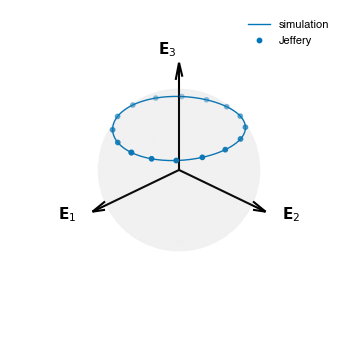

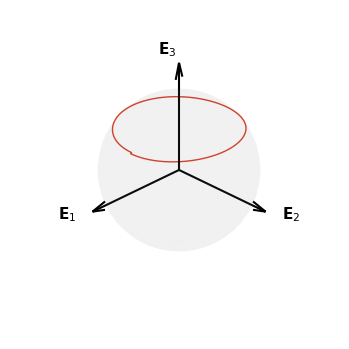

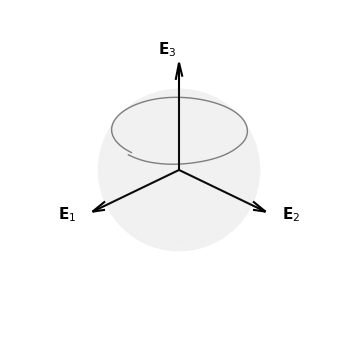

In [8]:
case_colors = {"rigid":  figstyle.COLORS["blue"],
               "medium": figstyle.COLORS["red"],
               "soft":   figstyle.COLORS["grey"]}
case_labels = {"rigid":  r"rigid ($k\to\infty$)",
               "medium": r"medium $k=1$",
               "soft":   r"soft $k=0.1$"}

# Analytical Jeffery orbit on the natural axis (for the rigid overlay)
duration = int(T_jeffery / dt)
phi_J, theta_J = jeffery_phi_theta(B, phi0_J, theta0_J, t[:duration], SHEAR_RATE)
p_jeffery = np.column_stack([
    np.sin(theta_J) * np.cos(phi_J),
    np.sin(theta_J) * np.sin(phi_J),
    np.cos(theta_J),
])

u_s, v_s = np.mgrid[0:2*np.pi:60j, 0:np.pi:30j]
stride = max(1, duration // 16)

for name, _, _ in cases:
    fig_s2, ax = figstyle.figure_3d(size="half", aspect=1.0)
    ax.plot_surface(
        0.998 * np.cos(u_s) * np.sin(v_s),
        0.998 * np.sin(u_s) * np.sin(v_s),
        0.998 * np.cos(v_s),
        color=figstyle.COLORS["grey"], alpha=0.05,
        linewidth=0, antialiased=True, shade=False,
    )
    figstyle.add_body_axes(ax, length=1.5, show_labels=True)
    figstyle.displace_label(ax, "axis_label_E1", text=r"$\mathbf{E}_1$", offset=(0.3, 0, 0))
    figstyle.displace_label(ax, "axis_label_E2", text=r"$\mathbf{E}_2$", offset=(0, 0.3, 0))
    figstyle.displace_label(ax, "axis_label_E3", text=r"$\mathbf{E}_3$", offset=(0.2, 0, 0))

    p = angles[name]["p"][:duration]
    ax.plot(p[:, 0], p[:, 1], p[:, 2],
            color=case_colors[name], linewidth=1.0, label="simulation")
    if name == "rigid":
        ax.scatter(p_jeffery[::stride, 0], p_jeffery[::stride, 1], p_jeffery[::stride, 2],
                   color=case_colors[name], s=10, label="Jeffery")
        ax.legend(loc="upper right", frameon=False, fontsize=8)

    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)
    ax.set_zlim(-1.2, 1.2)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])

    figstyle.save(fig_s2, f"fig_proto21_S2_{name}", figdir=FIGDIR)

## 7. Time series of $(\theta, \varphi, \gamma, \theta_\mathrm{dof})$

Two figures, one per time range:

* **`fig_proto21_angles_short`** — two Jeffery periods (the
  short-time orbital structure).
* **`fig_proto21_angles_long`** — the full 100 Jeffery periods (the
  long-time drift in the soft cases).

Each figure has four stacked panels for $\theta$, $\varphi$, $\gamma$
and the internal DOF $\theta_\mathrm{dof}$.  The three cases (rigid,
medium, soft) are overlaid in different colors.  $\varphi$ and
$\gamma$ are kept on $(-\pi, \pi]$ (no unwrap), so the sawtooth jumps
at the branch cut are visible.  For the rigid case there is no internal
DOF and $\theta_\mathrm{dof}(t) = 0$ identically.


1 extra bytes in post.stringData array


'created' timestamp seems very low; regarding as unix timestamp


1 extra bytes in post.stringData array


'created' timestamp seems very low; regarding as unix timestamp


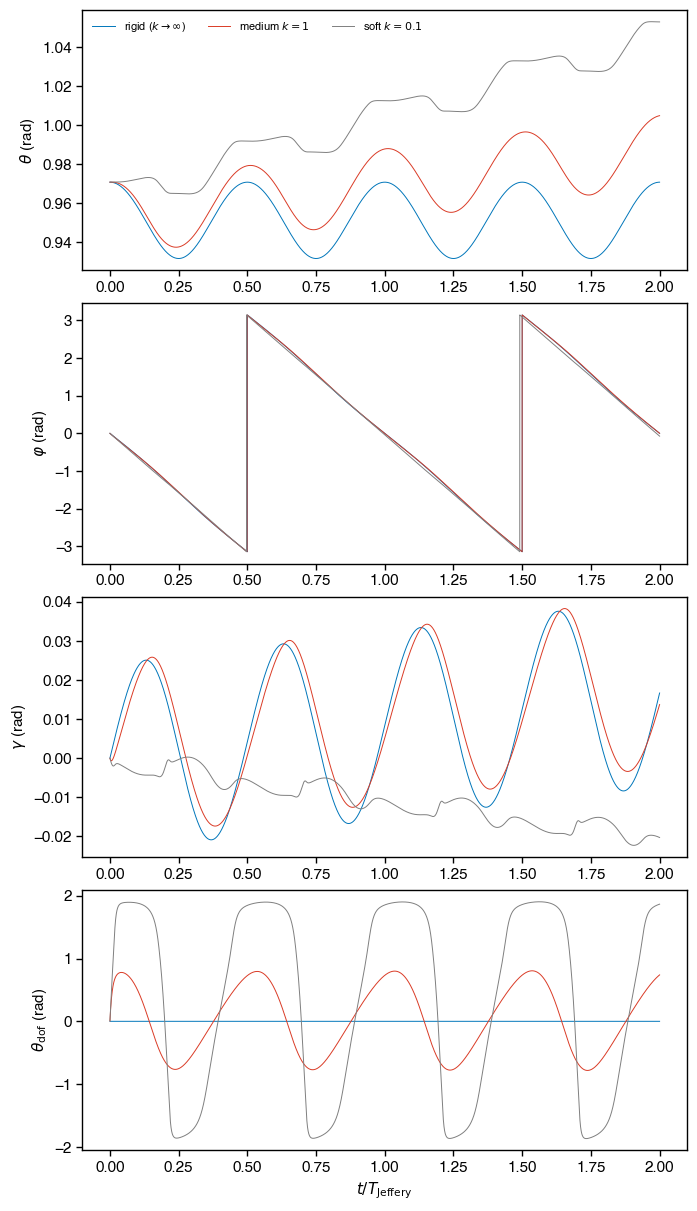

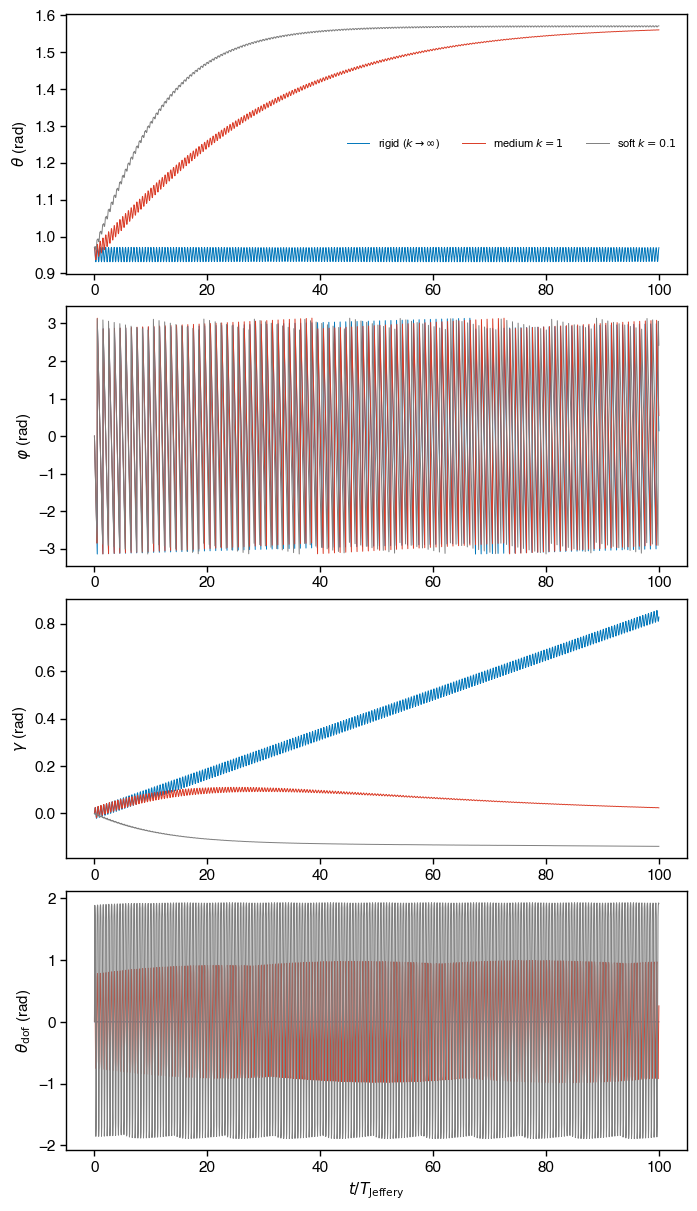

In [9]:
def plot_angle_timeseries(t_slice, angles_slice, fname):
    fig, axes = figstyle.subplots(size="full", aspect=400 / 700, ncols=1, nrows=4)
    tn = t_slice / T_jeffery

    for name in ("rigid", "medium", "soft"):
        a = angles_slice[name]
        axes[0].plot(tn, a["theta"], color=case_colors[name],
                     linewidth=0.7, label=case_labels[name])
        axes[1].plot(tn, a["phi"],   color=case_colors[name], linewidth=0.7)
        axes[2].plot(tn, a["gamma"], color=case_colors[name], linewidth=0.7)
        axes[3].plot(tn, a["dof"],   color=case_colors[name], linewidth=0.7)

    axes[0].set_ylabel(r"$\theta$ (rad)")
    axes[1].set_ylabel(r"$\varphi$ (rad)")
    axes[2].set_ylabel(r"$\gamma$ (rad)")
    axes[3].set_ylabel(r"$\theta_\mathrm{dof}$ (rad)")
    axes[3].set_xlabel(r"$t / T_\mathrm{Jeffery}$")
    axes[0].legend(loc="best", frameon=False, fontsize=8, ncol=3)

    figstyle.save(fig, fname, figdir=FIGDIR)


# ── Short range: first two Jeffery periods, no stride needed ──
n_short = int(2 * T_jeffery / dt)
short_slice = {
    name: {k: angles[name][k][:n_short] for k in ("phi", "theta", "gamma", "dof")}
    for name in ("rigid", "medium", "soft")
}
plot_angle_timeseries(t[:n_short], short_slice, "fig_proto21_angles_short")

# ── Long range: full 100 Jeffery periods, stride for file size ──
stride_long = max(1, len(t) // 2000)
long_slice = {
    name: {k: angles[name][k][::stride_long] for k in ("phi", "theta", "gamma", "dof")}
    for name in ("rigid", "medium", "soft")
}
plot_angle_timeseries(t[::stride_long], long_slice, "fig_proto21_angles_long")

## 8. Poincaré map of the soft case

For the soft case ($k = 0.1$) we sweep the initial polar angle
$\theta_0 \in (0, \pi)$ over 8 values (avoiding the singular poles)
and record $(\gamma, \theta)$ each time the trajectory crosses the
plane $\varphi = 0$ with $p_x > 0$ (positive-direction Poincaré
section).  Each color is one initial condition; runs are integrated
over $100$ Jeffery periods.

This is a few-minutes-long computation (8 × 1.26M RK4 steps).


  target θ₀=0.349  simulated θ(0)=0.349   100 Poincaré points


  target θ₀=0.698  simulated θ(0)=0.698   100 Poincaré points


  target θ₀=1.047  simulated θ(0)=1.047   100 Poincaré points


  target θ₀=1.396  simulated θ(0)=1.396   100 Poincaré points


  target θ₀=1.745  simulated θ(0)=1.745   100 Poincaré points


...

  target θ₀=2.443  simulated θ(0)=2.443   100 Poincaré points


1 extra bytes in post.stringData array


'created' timestamp seems very low; regarding as unix timestamp


  target θ₀=2.793  simulated θ(0)=2.793   100 Poincaré points


PosixPath('figures/fig_proto21_poincare_soft.pdf')

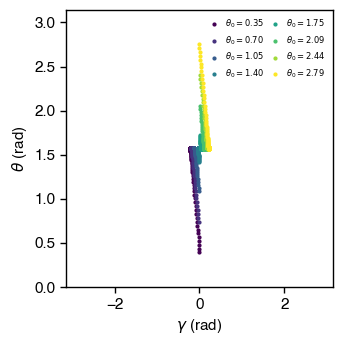

In [10]:
def poincare_section(phi, theta, gamma):
    """Return (theta, gamma) sampled at φ = 0 with positive crossings (p_x > 0)."""
    s = np.sin(phi)
    c = np.cos(phi)
    mask = (s[:-1] * s[1:] < 0) & (c[:-1] > 0) & (c[1:] > 0)
    idx = np.where(mask)[0]
    if idx.size == 0:
        return np.empty(0), np.empty(0)
    denom = s[idx + 1] - s[idx]
    frac = np.where(np.abs(denom) > 0, -s[idx] / denom, 0.0)
    th = theta[idx] + frac * (theta[idx + 1] - theta[idx])
    ga = gamma[idx] + frac * (gamma[idx + 1] - gamma[idx])
    return th, ga


# 8 ICs sweeping initial polar angle in (0, π).
# Rodrigues vector (0, -α, 0) rotates body x̂ to (cos α, 0, sin α) so
# θ(0) = π/2 − α.  To sweep θ(0) over (0, π), use α = π/2 − θ_target.
theta0_targets = np.linspace(0.0, np.pi, 10)[1:-1]
soft_design = jnp.asarray([a_small, length, 0.1])
soft_rollout = sm.FlowBodyRollout(soft_body=mybody, flow=shear_flow)

poincare_data = []
for th0 in theta0_targets:
    alpha = float(np.pi / 2 - th0)
    init_ori = jnp.array([0.0, -alpha, 0.0])
    _, oris_p, _ = soft_rollout.rollout(
        dt=dt, n_steps=n_steps, init_orientation=init_ori, design=soft_design
    )
    phi_p, theta_p, gamma_p = np.array(jax.vmap(
        lambda o: phi_theta_gamma_from_ori(o, e_nat_jnp, e_perp_jnp))(oris_p))
    th_sec, ga_sec = poincare_section(phi_p, theta_p, gamma_p)
    poincare_data.append({"theta0": float(th0),
                          "theta_init": float(theta_p[0]),
                          "th": th_sec, "ga": ga_sec})
    print(f"  target θ₀={th0:.3f}  simulated θ(0)={theta_p[0]:.3f}  "
          f"{len(th_sec):>4d} Poincaré points")


fig_p, ax_p = figstyle.figure(size="half", aspect=1.0)
cmap = plt.get_cmap("viridis")
n_ics = len(poincare_data)
for k, d in enumerate(poincare_data):
    col = cmap(k / max(1, n_ics - 1))
    ax_p.scatter(d["ga"], d["th"], s=4, color=col,
                 label=fr"$\theta_0 = {d['theta_init']:.2f}$")
ax_p.set_xlabel(r"$\gamma$ (rad)")
ax_p.set_ylabel(r"$\theta$ (rad)")
ax_p.set_xlim(-np.pi, np.pi)
ax_p.set_ylim(0.0, np.pi)
ax_p.legend(loc="upper right", frameon=False, fontsize=6, ncol=2,
            handlelength=1.0, columnspacing=0.8)
figstyle.save(fig_p, "fig_proto21_poincare_soft", figdir=FIGDIR)

## Summary

Body: $a_0 = 1$, $a_1 = 0.1$, $\ell = 0.2$.  Rigid-limit Bretherton
parameter $B \simeq 0.083$, Jeffery period $T \simeq 12.61$.

* **S² orbits.** Rigid simulation matches the closed-form Jeffery
  orbit; medium ($k = 1$) and soft ($k = 0.1$) cases show progressive
  drift across the sphere.
* **Time series.** Over the first two periods the three cases are
  nearly indistinguishable in $\theta$ and $\varphi$; over 100 periods
  the soft case accumulates visible drift, and the internal DOF
  $\theta_\mathrm{dof}$ tracks the elastic response of the cilium.
* **Poincaré map.** The soft case in the $(\gamma, \theta)$ plane at
  $\varphi = 0$ reveals the orbital-drift structure as a function of
  initial polar angle.
